In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
import matplotlib as mpl
import matplotlib.patches as patches
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'

In [2]:
def mvn_pdf(grid, mean, cov):
    """
    Multivariate normal PDF evaluated on a grid.
    grid: (..., 2) array of points
    mean: (2,)
    cov : (2,2)
    returns: (...) array
    """
    mean = np.asarray(mean, dtype=float)
    cov = np.asarray(cov, dtype=float)
    inv = np.linalg.inv(cov)
    det = np.linalg.det(cov)

    diff = grid - mean
    expo = -0.5 * np.einsum("...i,ij,...j->...", diff, inv, diff)
    norm = 1.0 / np.sqrt((2.0 * np.pi) ** 2 * det)
    return norm * np.exp(expo)

def mixture_pdf(grid, means, covs, weights=None):
    means = np.asarray(means, dtype=float)
    k = means.shape[0]

    if weights is None:
        weights = np.ones(k, dtype=float) / k
    else:
        weights = np.asarray(weights, dtype=float)
        weights = weights / weights.sum()

    out = np.zeros(grid.shape[:-1], dtype=float)
    for w, m, c in zip(weights, means, covs):
        out += w * mvn_pdf(grid, m, c)
    return out

def quantile_levels(Z, qs=(0.80, 0.88, 0.93, 0.96, 0.985, 0.995, 1.0), eps=1e-15):
    """
    Choose contour levels from quantiles of the positive values of Z
    for nicely spaced lines.
    """
    Zpos = Z[Z > eps]
    if Zpos.size == 0:
        raise ValueError("Z has no positive values above eps; check your PDF/grid.")
    return np.quantile(Zpos, qs)

def transparent_cmap(color, name):
    """
    Create a colormap that fades from transparent to the given color.
    """
    return LinearSegmentedColormap.from_list(
        name,
        [(0, (*color, 0.0)), (1, (*color, 1.0))]
    )

def alpha_fade_cmap(rgb, name, n=256, alpha_max=0.55, gamma=2.2):
    """
    rgb: tuple in [0,1]
    alpha_max: cap peak opacity (smaller = less strong at max)
    gamma > 1: slower fade near low values (less "too fast" fade)
    """
    t = np.linspace(0, 1, n)
    a = alpha_max * (t ** gamma)  # slow ramp
    colors = np.column_stack([
        np.full(n, rgb[0]),
        np.full(n, rgb[1]),
        np.full(n, rgb[2]),
        a
    ])
    return ListedColormap(colors, name=name)

def log_levels(Z, n_levels=120, floor_frac=1e-4):
    """
    Log-spaced levels from (max * floor_frac) .. max.
    Gives nicer tail structure and avoids over-saturating peaks.
    """
    zmax = float(np.max(Z))
    zmin = zmax * floor_frac
    return np.geomspace(zmin, zmax, n_levels)

(500, 500)


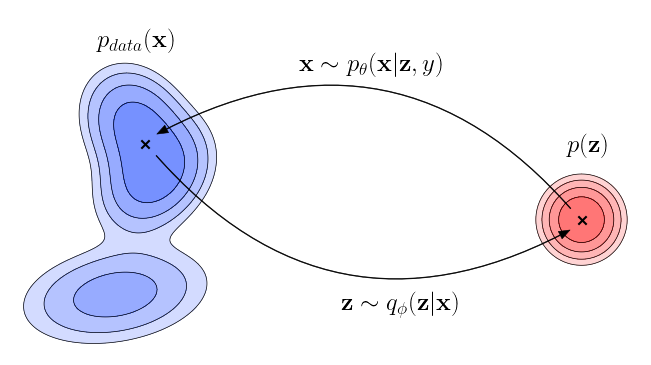

In [3]:
lim = 12.0
n = 500
x = np.linspace(-lim, lim, n)
y = np.linspace(-lim, lim, n)
xx, yy = np.meshgrid(x, y)
grid = np.stack([xx, yy], axis=-1)

# ----- Unit Gaussian prior (blue), centered at origin -----
prior_mean = np.array([8.0, 0.0])
prior_cov  = np.eye(2)*.5  # unit Gaussian
prior = mvn_pdf(grid, prior_mean, prior_cov)
print(prior.shape)
# ----- Mixture of 3 Gaussians (red), overlapping allowed -----
# Put the mixture as a whole away from the origin so it is separated from the prior.


means = np.array([
    [-7.5,  -2.5],
    [-6.8,  3.1],
    [-6.2,  1.4],
])

# Covariances chosen to allow overlap (not super tight).
covs = np.array([
    [[3.2,  0.4],
    [0.4,  0.9]],

    [[0.9, -0.2],
    [-0.2, 1.1]],

    [[1.0,  0.3],
    [0.3,  1.0]],
])

weights = np.array([0.33, 0.34, 0.33])
mix = mixture_pdf(grid, means, covs, weights)


# ----- Plot: same axes, blue prior + red mixture -----
fig, ax = plt.subplots(layout="constrained")
ax.set_xlim([-11.0,10.0])
ax.set_ylim([-4.5,7])
prior_levels = log_levels(prior, n_levels=5, floor_frac=0.1)
mix_levels   = log_levels(mix,   n_levels=5, floor_frac=0.1)

# Colormaps with tuned opacity + fade
blue_cmap = alpha_fade_cmap((0.0, 0.2, 1.0), "blue_alpha", alpha_max=0.6, gamma=0.4)
red_cmap  = alpha_fade_cmap((1.0, 0.0, 0.0), "red_alpha",  alpha_max=0.6, gamma=0.4)

ax.contour(xx, yy, prior, levels=prior_levels, colors="k", linewidths=0.5)
ax.contourf(xx, yy, prior, levels=prior_levels, cmap=red_cmap)
# Red mixture contours
ax.contour(xx, yy, mix, levels=mix_levels, colors="k", linewidths=0.5)
ax.contourf(xx, yy, mix, levels=mix_levels, cmap=blue_cmap)

style = "Simple, tail_width=0.5, head_width=6, head_length=8"
kw = dict(arrowstyle=style, color="k", linewidth=0.4)
ax.scatter(x=np.array([-6.5, 8.0]), y=np.array([2.5, 0.0]), c="k", marker="x")

fontsize=18

offset = 0.3
a1 = patches.FancyArrowPatch((-6.5+offset, 2.5-offset), (8.0-offset, 0.0-offset),
                             connectionstyle="arc3,rad=.4", **kw)
a2 = patches.FancyArrowPatch((8.0-offset, 0.0+offset), (-6.5+offset, 2.5+offset),
                             connectionstyle="arc3,rad=.4", **kw)

ax.annotate(text="$p_{data}(\mathbf{x})$", xy=(np.mean(means[:,0]), 6.0), fontsize=fontsize, ha="center", va="center")
ax.annotate(text="$p(\mathbf{z})$", xy=(prior_mean[0]+0.2, 2.5), fontsize=fontsize, ha="center", va="center")
ax.annotate(text="$\mathbf{z}\sim q_{\phi}(\mathbf{z} | \mathbf{x})$", xy=(2.0, -2.8), fontsize=fontsize, ha="center", va="center")
ax.annotate(text=r"$\mathbf{x}\sim p_{\theta}(\mathbf{x} | \mathbf{z},y)$", xy=(1.0, 5.2), fontsize=fontsize, ha="center", va="center")
plt.gca().add_patch(a1)
plt.gca().add_patch(a2)
ax.axis("off")
ax.set_aspect("equal")
plt.savefig("latent_model.pdf", bbox_inches='tight')